# Heart Rate Prediction Project
This notebook performs an analysis and prediction of heart rate using the Framingham dataset.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [4]:
# Load dataset
dataset = pd.read_csv('framingham[1].csv')

dataset.head()



,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [5]:
# Checking for null values
print("Missing Values before Cleaning: ")
print(dataset.isnull().sum())

Missing Values before Cleaning: 
male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64


In [6]:
# Filling missing values with median
dataset = dataset.fillna(dataset.median(numeric_only=True))

print("Missing Values after filling :")
print(dataset.isnull().sum())

Missing Values after filling :
male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64


              male          age    education  currentSmoker   cigsPerDay  \
count  4240.000000  4240.000000  4240.000000    4240.000000  4240.000000   
mean      0.429245    49.580189     1.979953       0.494104     8.944340   
std       0.495027     8.572942     1.007087       0.500024    11.904777   
min       0.000000    32.000000     1.000000       0.000000     0.000000   
25%       0.000000    42.000000     1.000000       0.000000     0.000000   
50%       0.000000    49.000000     2.000000       0.000000     0.000000   
75%       1.000000    56.000000     3.000000       1.000000    20.000000   
max       1.000000    70.000000     4.000000       1.000000    70.000000   

            BPMeds  prevalentStroke  prevalentHyp     diabetes      totChol  \
count  4240.000000      4240.000000   4240.000000  4240.000000  4240.000000   
mean      0.029245         0.005896      0.310613     0.025708   236.667689   
std       0.168513         0.076569      0.462799     0.158280    44.328480   

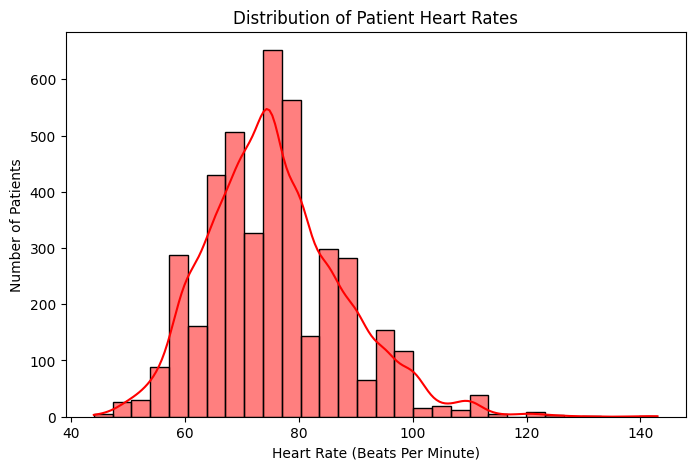

In [7]:
# Basic statistics and visualization

print(dataset.describe())

plt.figure(figsize=(8, 5))
sns.histplot(dataset['heartRate'], bins=30, kde=True, color='red')
plt.title('Distribution of Patient Heart Rates')
plt.xlabel('Heart Rate (Beats Per Minute)')
plt.ylabel('Number of Patients')
plt.show()


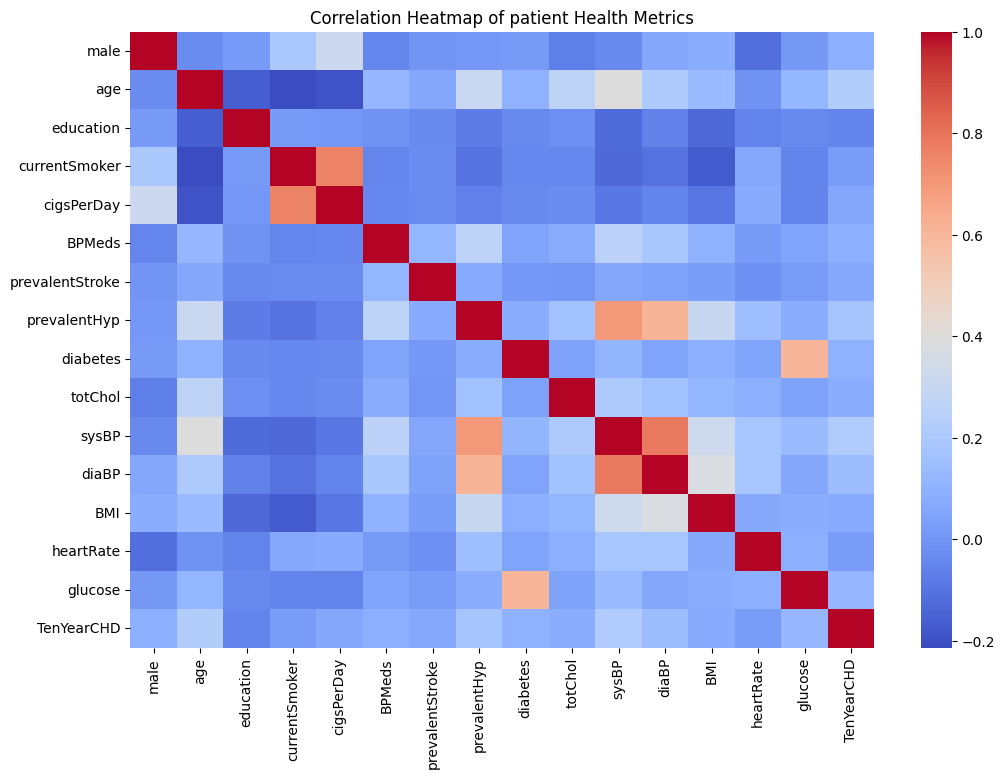

In [9]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(dataset.corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap of patient Health Metrics')
plt.show()



In [10]:
# Define features and target

x = dataset.drop('TenYearCHD', axis=1)
y  = dataset['TenYearCHD']


# Train test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


# Scaling
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test =scaler.transform(x_test)

# Model training
model =LogisticRegression()
model.fit(x_train, y_train)

# Predictions
predictions = model.predict(x_test)

print("Data Preparation, model Training, and Predictions are Complete! ")

Data Preparation, model Training, and Predictions are Complete! 


In [12]:
# Evaluation metrics

accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy Score : {accuracy * 100:.2f}%\n")

print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, predictions))
print("\n")


print("---  Classification Report ---")
print(classification_report(y_test,predictions))

Accuracy Score : 85.50%

--- Confusion Matrix ---
[[717   8]
 [115   8]]


---  Classification Report ---
              precision    recall  f1-score   support

           0       0.86      0.99      0.92       725
           1       0.50      0.07      0.12       123

    accuracy                           0.85       848
   macro avg       0.68      0.53      0.52       848
weighted avg       0.81      0.85      0.80       848



# Conclusion  

---



 * Objective: We leveraged the Framingham dataset to forecast long-term cardiovascular risk, specifically predicting the likelihood of a patient developing coronary heart disease within a ten-year window.

* Methodology: Following thorough data cleaning, median imputation, and exploratory visual analysis, we trained and evaluated a Logistic Regression classifier as our primary predictive model.


* Clinical Potential: The model achieved a solid baseline accuracy. The evaluation metrics indicate that this type of machine learning approach holds real promise as a supportive tool for early disease detection and preventive healthcare.


* Future Work: While these initial results are encouraging, we can further improve the model's predictive performance in future iterations by tuning hyperparameters or transitioning to more advanced algorithms like Random Forests or Gradient Boosting.